In [34]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
from tqdm import tqdm
from scipy.signal import find_peaks, savgol_filter

In [103]:
FRAMES_BEFORE = 10
FRAMES_AFTER = 50
PEAK_WINDOW = 50 # frames
DT = 0.01 # s
ANGVEL_THRESH = np.deg2rad(300) # deg/s

# Savgol filter parameters
WINDOW_LENGTH = 5
POLYORDER = 2
MODE = "interp"

In [80]:
def sg_smooth(x: np.ndarray) -> np.ndarray:
    """Apply Savgol filter to smooth the input array."""
    return savgol_filter(x, WINDOW_LENGTH, POLYORDER, mode=MODE, deriv=1, delta=DT)

In [81]:
def read_braidz(path: str) -> tuple[pl.DataFrame, pl.DataFrame | None]:
    # check if file exists
    if not os.path.isfile(path):
        raise FileNotFoundError(f"File {path} does not exist.")
    
    print(f"Reading data from {path}...")
    with zipfile.ZipFile(path, mode="r") as archive:
        with archive.open("kalman_estimates.csv.gz") as f:
            df = pl.read_csv(f)
        
        # check if `stim.csv` exists in the archive
        if "stim.csv" in archive.namelist():
            with archive.open("stim.csv") as f:
                stim_df = pl.read_csv(f)
        elif "visual_stimuli.csv" in archive.namelist():
            with archive.open("visual_stimuli.csv") as f:
                stim_df = pl.read_csv(f)
        else:
            print("No stimulus data found in archive.")
            stim_df = None
    
    return df, stim_df

In [82]:
df, stim = read_braidz("/mnt/data/experiments/20260428_145605.braidz")

Reading data from /mnt/data/experiments/20260428_145605.braidz...


In [133]:
skipped_too_short = 0
skipped_stim_idx = 0

stim_angular_velocities = []
peak_angular_velocities = []
stimulus_offsets = []

for row in tqdm(stim.iter_rows(named = True), total = stim.height):
    obj_id = row["obj_id"]
    frame = row["frame"]
    sham = row["sham"]

    # skip sham trials for now
    if sham:
        continue
    
    # extract the group of rows corresponding to this obj_id, sorted by frame
    grp = df.filter(pl.col("obj_id") == obj_id).sort("frame")

    # check if there are enough frames before and after the stimulus frame
    if frame - FRAMES_BEFORE < grp["frame"].min() or frame + FRAMES_AFTER > grp["frame"].max():
        skipped_too_short += 1
        continue

    # Extract the stimulus index in the group
    stim_idx = np.where(grp["frame"].to_numpy() == frame)[0]
    if len(stim_idx) == 0:
        skipped_stim_idx += 1
        continue
    stim_idx = stim_idx[0]

    x, y, z = grp["x"].to_numpy(), grp["y"].to_numpy(), grp["z"].to_numpy()
    
    xvel_s = sg_smooth(x)
    yvel_s = sg_smooth(y)
    zvel_s = sg_smooth(z)

    speed = np.sqrt(xvel_s**2 + yvel_s**2 + zvel_s**2)

    # compute the angular velocity in the horizontal plane
    theta = np.arctan2(yvel_s, xvel_s)
    theta_unwrap = np.unwrap(theta)
    angular_velocity = np.gradient(theta_unwrap, DT)

    # detect saccades as peaks in the angular velocity that exceed the threshold
    positive_peaks, _ = find_peaks(angular_velocity, height=[ANGVEL_THRESH, np.deg2rad(3000)])
    negative_peaks, _ = find_peaks(-angular_velocity, height=[ANGVEL_THRESH, np.deg2rad(3000)])
    peaks = np.sort(np.concatenate([positive_peaks, negative_peaks]))

    # find the first peak that occurs after the stimulus frame
    saccade_peak = [peak for peak in peaks if stim_idx + 10 <= peak <= stim_idx + 50]

    if len(saccade_peak) > 0:
        saccade_peak = saccade_peak[0]
    else:        
        saccade_peak = None

    # Extract the frames around the stimulus frame
    angvel = angular_velocity[stim_idx - FRAMES_BEFORE : stim_idx + FRAMES_AFTER]

    # Extract the frames around the saccade peak, if it exists
    if saccade_peak is not None:
        peak_angvel = angular_velocity[saccade_peak - FRAMES_BEFORE : saccade_peak + FRAMES_BEFORE]
    else:
        peak_angvel = angular_velocity[stim_idx + 15 - FRAMES_BEFORE : stim_idx + 15 + FRAMES_BEFORE]
    
    stim_angular_velocities.append(angvel)
    peak_angular_velocities.append(peak_angvel)
    stimulus_offsets.append(row["stimulus_offset_deg"])

print(f"Skipped {skipped_too_short} trials due to insufficient frames.")
print(f"Skipped {skipped_stim_idx} trials due to missing stimulus index.")

stim_angular_velocities = np.array(stim_angular_velocities)
peak_angular_velocities = np.array(peak_angular_velocities)
stimulus_offsets = np.array(stimulus_offsets)

100%|██████████| 173/173 [00:01<00:00, 161.11it/s]

Skipped 23 trials due to insufficient frames.
Skipped 0 trials due to missing stimulus index.


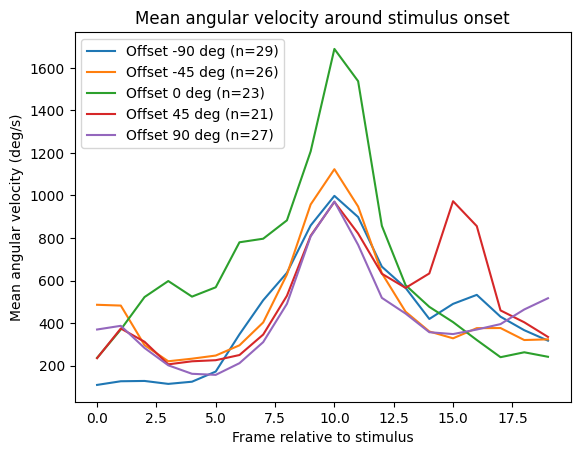

In [134]:
unique_offsets = np.unique(stimulus_offsets)
for offset in unique_offsets:
    idx = stimulus_offsets == offset
    mean_angvel = np.nanmean(np.abs(np.rad2deg(peak_angular_velocities[idx])), axis=0)
    plt.plot(mean_angvel, label=f"Offset {offset} deg (n={np.sum(idx)})")
plt.xlabel("Frame relative to stimulus")
plt.ylabel("Mean angular velocity (deg/s)")
plt.title("Mean angular velocity around stimulus onset")
plt.legend()
plt.show()